Accuracy: 0.999


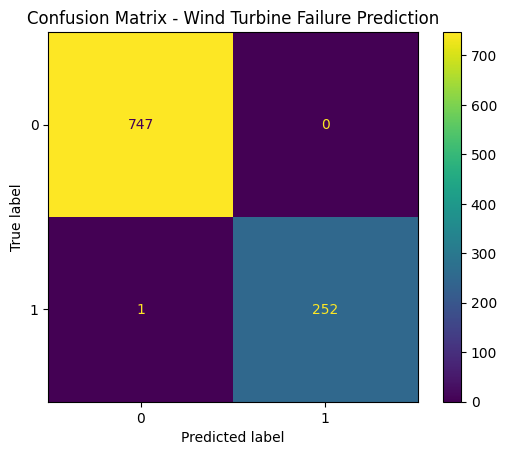

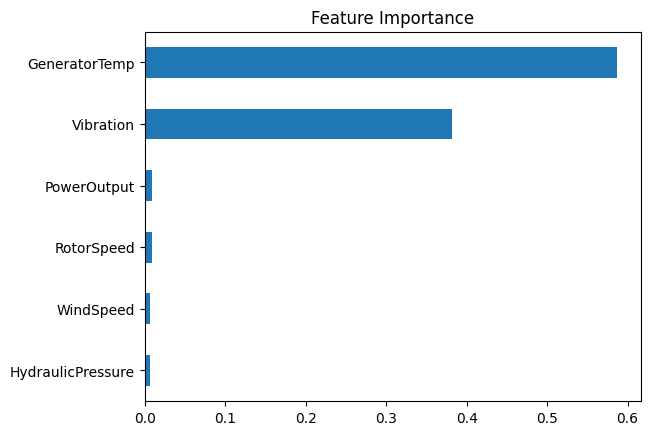

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, ConfusionMatrixDisplay
np.random.seed(42)
n = 5000

data = pd.DataFrame({
    'WindSpeed': np.random.uniform(5, 25, n),
    'RotorSpeed': np.random.uniform(20, 45, n),
    'GeneratorTemp': np.random.uniform(50, 110, n),
    'Vibration': np.random.uniform(0.1, 2.5, n),
    'PowerOutput': np.random.uniform(1000, 2500, n),
    'HydraulicPressure': np.random.uniform(100, 170, n)
})
data['Failure'] = (
    (data['GeneratorTemp'] > 85) &
    (data['Vibration'] > 1.2)
).astype(int)
X = data.drop("Failure", axis=1)
y = data["Failure"]
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

model = RandomForestClassifier(n_estimators=100, random_state=42)
model.fit(X_train, y_train)

y_pred = model.predict(X_test)

accuracy = accuracy_score(y_test, y_pred)
print("Accuracy:", accuracy)
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot()
plt.title("Confusion Matrix - Wind Turbine Failure Prediction")
plt.show()
importance = pd.Series(model.feature_importances_, index=X.columns)
importance.sort_values().plot(kind='barh')
plt.title("Feature Importance")
plt.show()